# ✈️ NASA C-MAPSS FD004 — 전처리 조합 실험 파이프라인

** CONFIG 기반 전처리 조합 실험 / DL Long Format CSV 저장 / random_state=42 엔진 분할

공통: 상수 센서 제거 → RUL cap → Gaussian → Validation 분할 → 정규화
DL 분기: 슬라이딩 윈도우 → Long Format CSV 저장

이번 버전은 **가우시안 스무딩 → 엔진 단위 랜덤 validation 분리(random_state=42) → sub-train 기준 정규화 → ML/DL 분기 처리** 흐름으로 구성했습니다.



# 전처리 실험에서 편하게 하기 위해서 FD002,3과 동일하게 전처리 실험 함수 유지

## 0. 환경 설정

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
import joblib
import json
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp, kendalltau, mannwhitneyu, levene, ttest_rel, shapiro, wilcoxon
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────────────────────
import logging
import matplotlib.font_manager as fm
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

def force_korean_font():
    system = platform.system()
    if system == "Windows":
        font_path = "C:/Windows/Fonts/malgun.ttf"
        font_name = "Malgun Gothic"
    elif system == "Darwin":
        font_path = "/System/Library/Fonts/AppleGothic.ttf"
        font_name = "AppleGothic"
    else:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        font_name = "NanumGothic"
        if not os.path.exists(font_path):
            os.system("apt-get update -qq")
            os.system("apt-get install -y fonts-nanum -qq")
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 한글 폰트 적용: {font_name}")
    else:
        print("❌ 폰트 못 찾음")

force_korean_font()

# ── 다크 테마 ─────────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})
force_korean_font()

# ── 전역 상수 ─────────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
CLUSTER_COLORS = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8']

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
CONST_THR    = 0.01
N_CLUSTERS     = 6

# ── 수동 제거/유지 센서 ─────────────────────────────────────────────────────────────
MANUAL_REMOVE = ['s_1', 's_5', 's_6', 's_18', 's_19']
MANUAL_KEEP   = []

# ── 센서 분류 (EDA 시각화용) ──────────────────────────────────────────────
FAN_SENSORS = ['s_1','s_6','s_8','s_13','s_15']
HPC_SENSORS = ['s_3','s_7','s_9','s_11','s_12']

TEMPORAL_LAGS      = [1, 3, 5]
TEMPORAL_DIFFS     = [1]
TEMPORAL_ROLLS     = [3, 5]
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS      = [5]

# ── 전처리 실험 CONFIG ────────────────────────────────────────────────────
CONFIG = {
    'RUL_CAP'      : 125,      # 실험: 125 / 120, 130 
    'GAUSS_SIGMA'  : 2,        # 실험: 2 /  0, 1, 3
    'WINDOW_SIZE'  : 30,       # 실험: 30 /  20, 10
    'SCALER_TYPE'  : 'minmax' , # 실험: 'standard' , 'minmax'
    'VALID_RATIO'  : 0.2,
    'RANDOM_STATE' : 42,
}

RUL_CAP      = CONFIG['RUL_CAP']
GAUSS_SIGMA  = CONFIG['GAUSS_SIGMA']
WINDOW_SIZE  = CONFIG['WINDOW_SIZE']
SCALER_TYPE  = CONFIG['SCALER_TYPE']
VALID_RATIO  = CONFIG['VALID_RATIO']
RANDOM_STATE = CONFIG['RANDOM_STATE']
STEP         = 1

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
print(f'   Window={WINDOW_SIZE}  |  Scaler={SCALER_TYPE}  |  N_Clusters={N_CLUSTERS}')
print(f'   수동 제거: {MANUAL_REMOVE}  |  수동 유지: {MANUAL_KEEP}')

✅ 한글 폰트 적용: Malgun Gothic
✅ 한글 폰트 적용: Malgun Gothic
✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01
   Window=30  |  Scaler=standard  |  N_Clusters=6
   수동 제거: ['s_1', 's_5', 's_6', 's_18', 's_19']  |  수동 유지: []


## 1. 데이터 로딩 & 컬럼명 표준화

In [2]:
DATA_DIR = '../YJ'

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD004.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD004.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD004.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD004 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD004 로딩 완료
   Train : (61249, 26)  |  엔진 249대
   Test  : (41214, 26)   |  엔진 248대
   RUL   : (248, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.0,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.0,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.0,10.48,6.4213


---
# FD003과 유사하게 사용해도 문제 없음을 확인하여 전처리 조합 실험셀은 FD003과 유사하게 맞춰서 진행함

## 파이프라인 함수 정의


In [3]:
# ============================================================
# 파이프라인 함수 정의
# ============================================================

# ── 결정 1: 센서 필터링 ──────────────────────────────────────
def filter_useful_sensors(train_df, sensor_cols, manual_remove, manual_keep, const_thr):
    """
    1. std < const_thr 인 센서 자동 제거
    2. manual_remove 센서 추가 제거 (std 무관)
    3. manual_keep 센서 강제 유지 (std < const_thr 이어도)
    → 데이터 누수 없음: train 기준으로만 판단, test에 동일 적용
    """
    train_std   = train_df[sensor_cols].std()
    auto_remove = train_std[train_std < const_thr].index.tolist()
    remove      = sorted(set(auto_remove + manual_remove) - set(manual_keep))
    useful      = sorted([s for s in sensor_cols if s not in remove],
                         key=lambda x: int(x.split('_')[1]))
    return useful, remove


# ── 결정 2: Piecewise RUL 생성 ───────────────────────────────
def add_piecewise_rul(df, cap=RUL_CAP):
    """
    엔진별 RUL 계산 후 cap 적용
    → train 전용. test RUL은 RUL_FD003.txt에서 직접 가져옴
    """
    df            = df.copy()
    mc            = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df            = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


# ── 결정 3: Gaussian 스무딩 ──────────────────────────────────
def apply_gaussian_by_unit(df, features, sigma=GAUSS_SIGMA):
    """
    엔진 단위 가우시안 스무딩
    → mode='nearest': 경계 처리 안정적
    → 데이터 누수 없음: 엔진 내부에서만 스무딩
    """
    if sigma == 0:  # ← 이 부분 추가
        return df.copy()
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    def _smooth(s):
        return gaussian_filter1d(
            s.values.astype(np.float32), sigma=sigma, mode='nearest'
        ) if len(s) > 1 else s.values
    for col in features:
        df[col] = df.groupby('unit_nr')[col].transform(_smooth)
    return df



# ── 결정 4: Validation 분할 ──────────────────────────────────
def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """
    엔진 단위 random split (행 단위 아님)
    → 동일 엔진 데이터가 train/valid에 동시에 들어가지 않음 (데이터 누수 방지)
    """
    units        = train_df['unit_nr'].unique()
    sub_u, val_u = train_test_split(units, test_size=valid_ratio, random_state=random_state)
    sub          = train_df[train_df['unit_nr'].isin(sub_u)].copy().reset_index(drop=True)
    val          = train_df[train_df['unit_nr'].isin(val_u)].copy().reset_index(drop=True)
    return sub, val, sub_u, val_u


# ── 결정 5: 클러스터별 정규화 (FD002/FD004 전용) ─────────────
def normalize_by_cluster(sub, val, test, features, cluster_col='op_cluster', method='minmax'):
    """
    클러스터별 정규화 (sub-train 기준 fit)
    → FD002/004는 운전 조건 6가지 → 클러스터별 MinMax 확정
    → fit은 sub-train만, valid/test는 transform만 (데이터 누수 방지)
    → 클러스터에 없는 경우 대비 전체 scaler fallback 포함
    """
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    
    sub  = sub.copy()
    val  = val.copy()
    test = test.copy()
    
    scalers = {}
    clusters = sorted(sub[cluster_col].unique())
    
    # sub-train 기준으로 클러스터별 fit
    for c in clusters:
        mask = sub[cluster_col] == c
        scaler = ScalerCls()
        sub.loc[mask, features] = scaler.fit_transform(sub.loc[mask, features])
        scalers[c] = scaler
    
    # fallback용 전체 scaler (sub-train 전체 기준)
    fallback_scaler = ScalerCls()
    fallback_scaler.fit(sub[features])  # 이미 정규화된 값 기준이라 실제론 거의 안 쓰임
    
    # valid/test는 transform만
    for df_ in [val, test]:
        for c in df_[cluster_col].unique():
            mask = df_[cluster_col] == c
            if c in scalers:
                df_.loc[mask, features] = scalers[c].transform(df_.loc[mask, features])
            else:
                # sub-train에 없던 클러스터 → fallback
                print(f'⚠️ 클러스터 {c} sub-train에 없음 → fallback scaler 적용')
                df_.loc[mask, features] = fallback_scaler.transform(df_.loc[mask, features])
    
    return sub, val, test, scalers


# ── DL 슬라이딩 윈도우 ────────────────────────────────────────
def create_sliding_windows(df, feature_cols, target_col=None,
                            window_size=WINDOW_SIZE, step=STEP):
    """
    Train/Valid용: 슬라이딩 윈도우 → (N, window, F)
    → 엔진 단위로 처리 → 엔진 경계에서 윈도우 생성 안 함 (데이터 오염 방지)
    """
    X_list, y_list = [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        tgt  = udf[target_col].values if target_col else None
        n    = len(data)
        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end-1])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y


def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    """
    Test용: 엔진별 마지막 window_size 사이클 → 1샘플씩
    → 사이클 수 < window_size 이면 앞에 zero-padding
    → rul_series: RUL_FD003.txt에서 로드한 실제 RUL값
    """
    X_list, y_list = [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def windows_to_long_df(X, y, feature_cols):
    """
    [벡터화] 3D 텐서 → Long Format DataFrame
    → reshape 한 번으로 생성 (루프 방식 대비 수십 배 빠름)
    컬럼: sample_id | timestep | 센서들 | RUL
    """
    n_samples, win_size, n_feat = X.shape
    sample_id = np.repeat(np.arange(n_samples), win_size)
    timestep  = np.tile(np.arange(win_size), n_samples)
    flat      = X.reshape(n_samples * win_size, n_feat)
    df        = pd.DataFrame(flat, columns=list(feature_cols))
    df.insert(0, 'timestep', timestep)
    df.insert(0, 'sample_id', sample_id)
    df['RUL'] = np.repeat(np.asarray(y, dtype=np.float32), win_size)
    return df


print('✅ 파이프라인 함수 정의 완료')
print('   filter_useful_sensors / add_piecewise_rul / apply_gaussian_by_unit')
print('   split_by_unit / normalize_global')
print('   create_sliding_windows / create_test_windows / windows_to_long_df')

✅ 파이프라인 함수 정의 완료
   filter_useful_sensors / add_piecewise_rul / apply_gaussian_by_unit
   split_by_unit / normalize_global
   create_sliding_windows / create_test_windows / windows_to_long_df


##  파이프라인 실행

In [4]:
# ── 결정 1: 센서 필터링 ──────────────────────────────────────
USEFUL_SENSORS, REMOVE_SENSORS = filter_useful_sensors(
    train_raw, SENSOR_COLS, MANUAL_REMOVE, MANUAL_KEEP, CONST_THR)
print(f'✅ 결정 1 완료')
print(f'   제거 ({len(REMOVE_SENSORS)}개): {REMOVE_SENSORS}')
print(f'   유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

KEEP     = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()

# ── KMeans 클러스터링 (FD002/FD004 전용) ───────────────────────────
op_scaler = MinMaxScaler()
train_op  = op_scaler.fit_transform(train_s1[OP_COLS])
test_op   = op_scaler.transform(test_s1[OP_COLS])

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(train_op)

train_s1['op_cluster'] = kmeans.predict(train_op)
test_s1['op_cluster']  = kmeans.predict(test_op)
print(f'\n✅ KMeans 클러스터링 완료  k={N_CLUSTERS}')
print(f'   클러스터 분포:\n{train_s1["op_cluster"].value_counts().sort_index()}')

# ── 결정 2: Piecewise RUL ────────────────────────────────────
train_s2 = add_piecewise_rul(train_s1)
print(f'\n✅ 결정 2 완료  RUL 범위: {train_s2["RUL"].min():.0f} ~ {train_s2["RUL"].max():.0f}')

# ── 결정 3: Gaussian 스무딩 ──────────────────────────────────
train_s3 = apply_gaussian_by_unit(train_s2, USEFUL_SENSORS)
test_s3  = apply_gaussian_by_unit(test_s1,  USEFUL_SENSORS)
print(f'\n✅ 결정 3 완료  σ={GAUSS_SIGMA}')

# ── 결정 4: Validation 분할 ──────────────────────────────────
subtrain, valid, subtrain_units, valid_units = split_by_unit(train_s3)
print(f'\n✅ 결정 4 완료')
print(f'   Sub-train: {subtrain["unit_nr"].nunique()}대  |  Validation: {valid["unit_nr"].nunique()}대')

# ── 결정 5: 클러스터별 정규화 ────────────────────────────────
subtrain_s4, valid_s4, test_s4, scalers = normalize_by_cluster(
    subtrain, valid, test_s3, USEFUL_SENSORS,
    cluster_col='op_cluster', method=SCALER_TYPE)
print(f'\n✅ 결정 5 완료  (클러스터별 {SCALER_TYPE})')

# ── OHE ──────────────────────────────────────────────────────
for df_ in [subtrain_s4, valid_s4, test_s4]:
    ohe = pd.get_dummies(df_['op_cluster'], prefix='cluster').astype(np.float32)
    for col in [f'cluster_{i}' for i in range(N_CLUSTERS)]:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    df_[[f'cluster_{i}' for i in range(N_CLUSTERS)]] = \
        ohe[[f'cluster_{i}' for i in range(N_CLUSTERS)]].values

DL_FEATURES = USEFUL_SENSORS + [f'cluster_{i}' for i in range(N_CLUSTERS)]
print(f'\n✅ OHE 완료  input_size={len(DL_FEATURES)}  (센서{len(USEFUL_SENSORS)} + OHE{N_CLUSTERS})')


✅ 결정 1 완료
   제거 (6개): ['s_1', 's_16', 's_18', 's_19', 's_5', 's_6']
   유지 (15개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

✅ KMeans 클러스터링 완료  k=6
   클러스터 분포:
op_cluster
0    15395
1     9224
2     9139
3     9091
4     9238
5     9162
Name: count, dtype: int64

✅ 결정 2 완료  RUL 범위: 0 ~ 125

✅ 결정 3 완료  σ=2

✅ 결정 4 완료
   Sub-train: 199대  |  Validation: 50대

✅ 결정 5 완료  (클러스터별 standard)

✅ OHE 완료  input_size=21  (센서15 + OHE6)


In [5]:
# ── DL 슬라이딩 윈도우 ────────────────────────────────────────
X_subtrain_dl, y_subtrain_dl = create_sliding_windows(subtrain_s4, DL_FEATURES, 'RUL')
X_valid_dl,    y_valid_dl    = create_sliding_windows(valid_s4,    DL_FEATURES, 'RUL')
X_test_dl,     y_test_dl     = create_test_windows(test_s4, DL_FEATURES, rul_df['RUL'])

print(f'\n✅ DL 슬라이딩 윈도우 완료  window={WINDOW_SIZE}  step={STEP}')
print(f'   X_subtrain: {X_subtrain_dl.shape}  y: {y_subtrain_dl.shape}')
print(f'   X_valid   : {X_valid_dl.shape}  y: {y_valid_dl.shape}')
print(f'   X_test    : {X_test_dl.shape}   y: {y_test_dl.shape}')

# ── Long Format 변환 ─────────────────────────────────────────
dl_subtrain_long = windows_to_long_df(X_subtrain_dl, y_subtrain_dl, DL_FEATURES)
dl_valid_long    = windows_to_long_df(X_valid_dl,    y_valid_dl,    DL_FEATURES)
dl_test_long     = windows_to_long_df(X_test_dl,     y_test_dl,     DL_FEATURES)

print(f'\n   Long Format — subtrain: {dl_subtrain_long.shape}')
print(f'   Long Format — valid   : {dl_valid_long.shape}')
print(f'   Long Format — test    : {dl_test_long.shape}')


✅ DL 슬라이딩 윈도우 완료  window=30  step=1
   X_subtrain: (43523, 30, 21)  y: (43523,)
   X_valid   : (10505, 30, 21)  y: (10505,)
   X_test    : (248, 30, 21)   y: (248,)

   Long Format — subtrain: (1305690, 24)
   Long Format — valid   : (315150, 24)
   Long Format — test    : (7440, 24)


# 전처리 후 검증

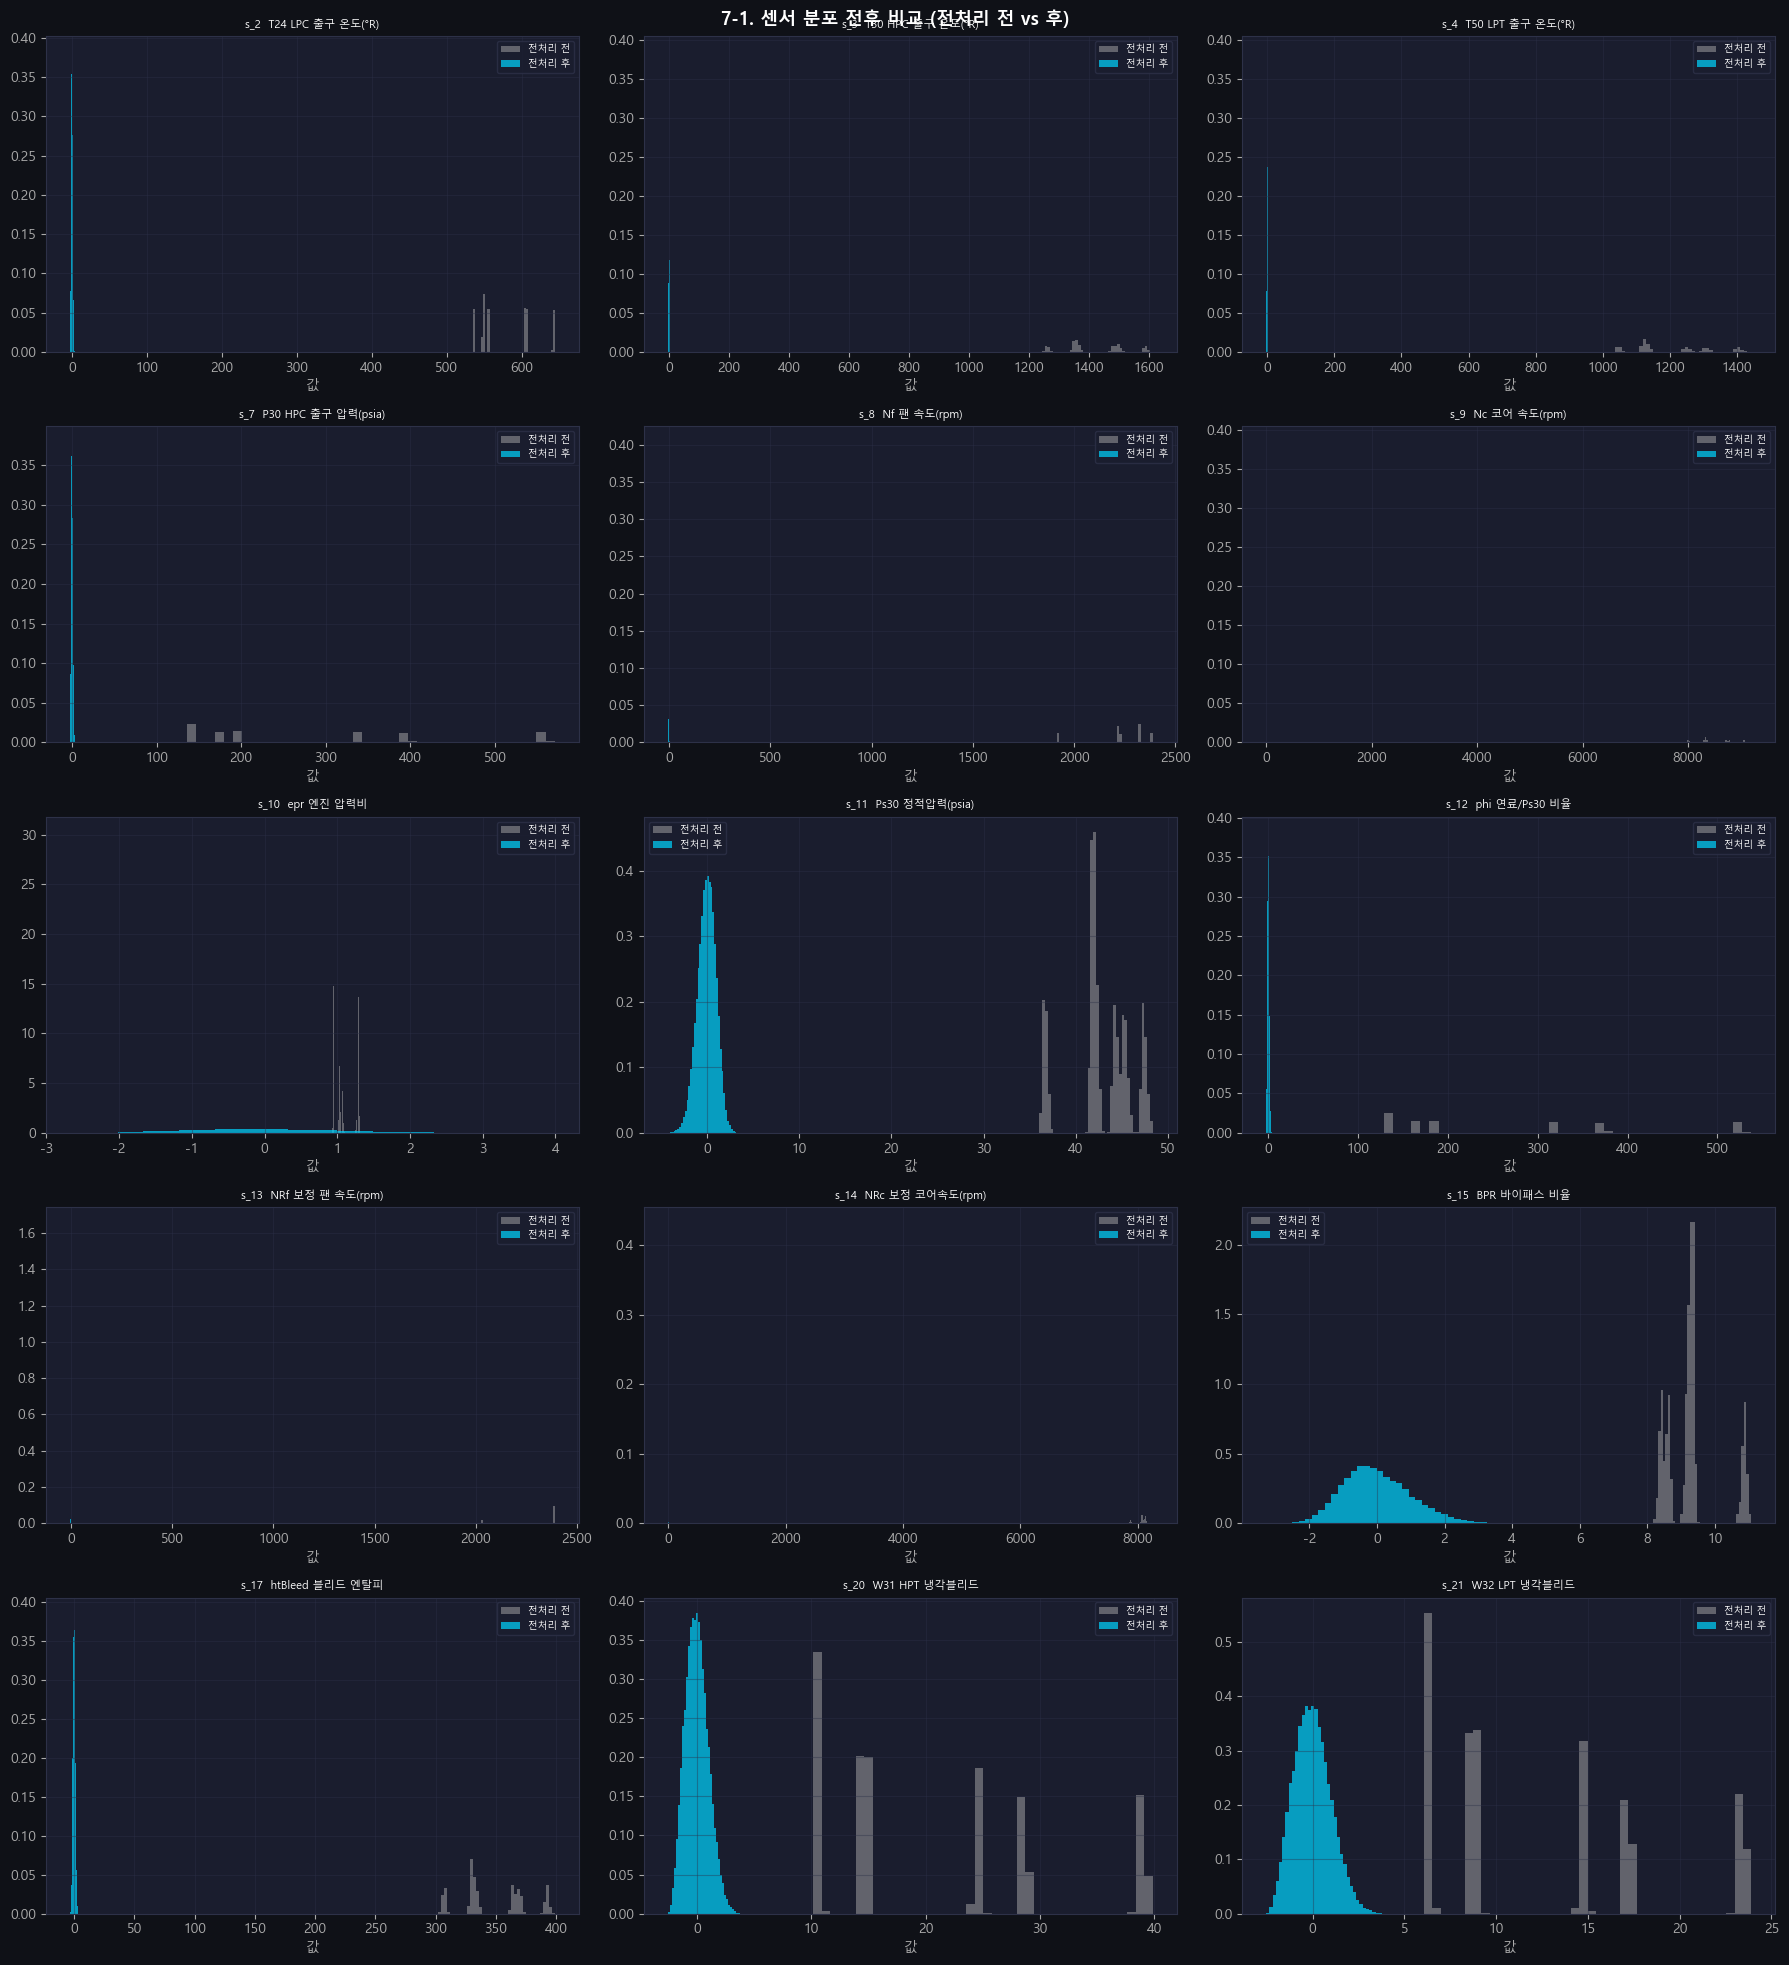

✅ 7-1 완료


In [6]:
# ============================================================
# 전처리 전후 검증 시각화
# ============================================================

# ── 7-1. 센서 분포 전후 비교 ─────────────────────────────────
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
fig.suptitle('7-1. 센서 분포 전후 비교 (전처리 전 vs 후)', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, USEFUL_SENSORS):
    before = train_raw[s].dropna()
    after  = subtrain_s4[s].dropna()
    ax.hist(before, bins=40, color=GRAY,  alpha=0.5, density=True, label='전처리 전')
    ax.hist(after,  bins=40, color=C[0],  alpha=0.7, density=True, label='전처리 후')
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")[:20]}', fontsize=8)
    ax.set_xlabel('값'); ax.legend(fontsize=7)

for ax in axes.flat[len(USEFUL_SENSORS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()
print('✅ 7-1 완료')

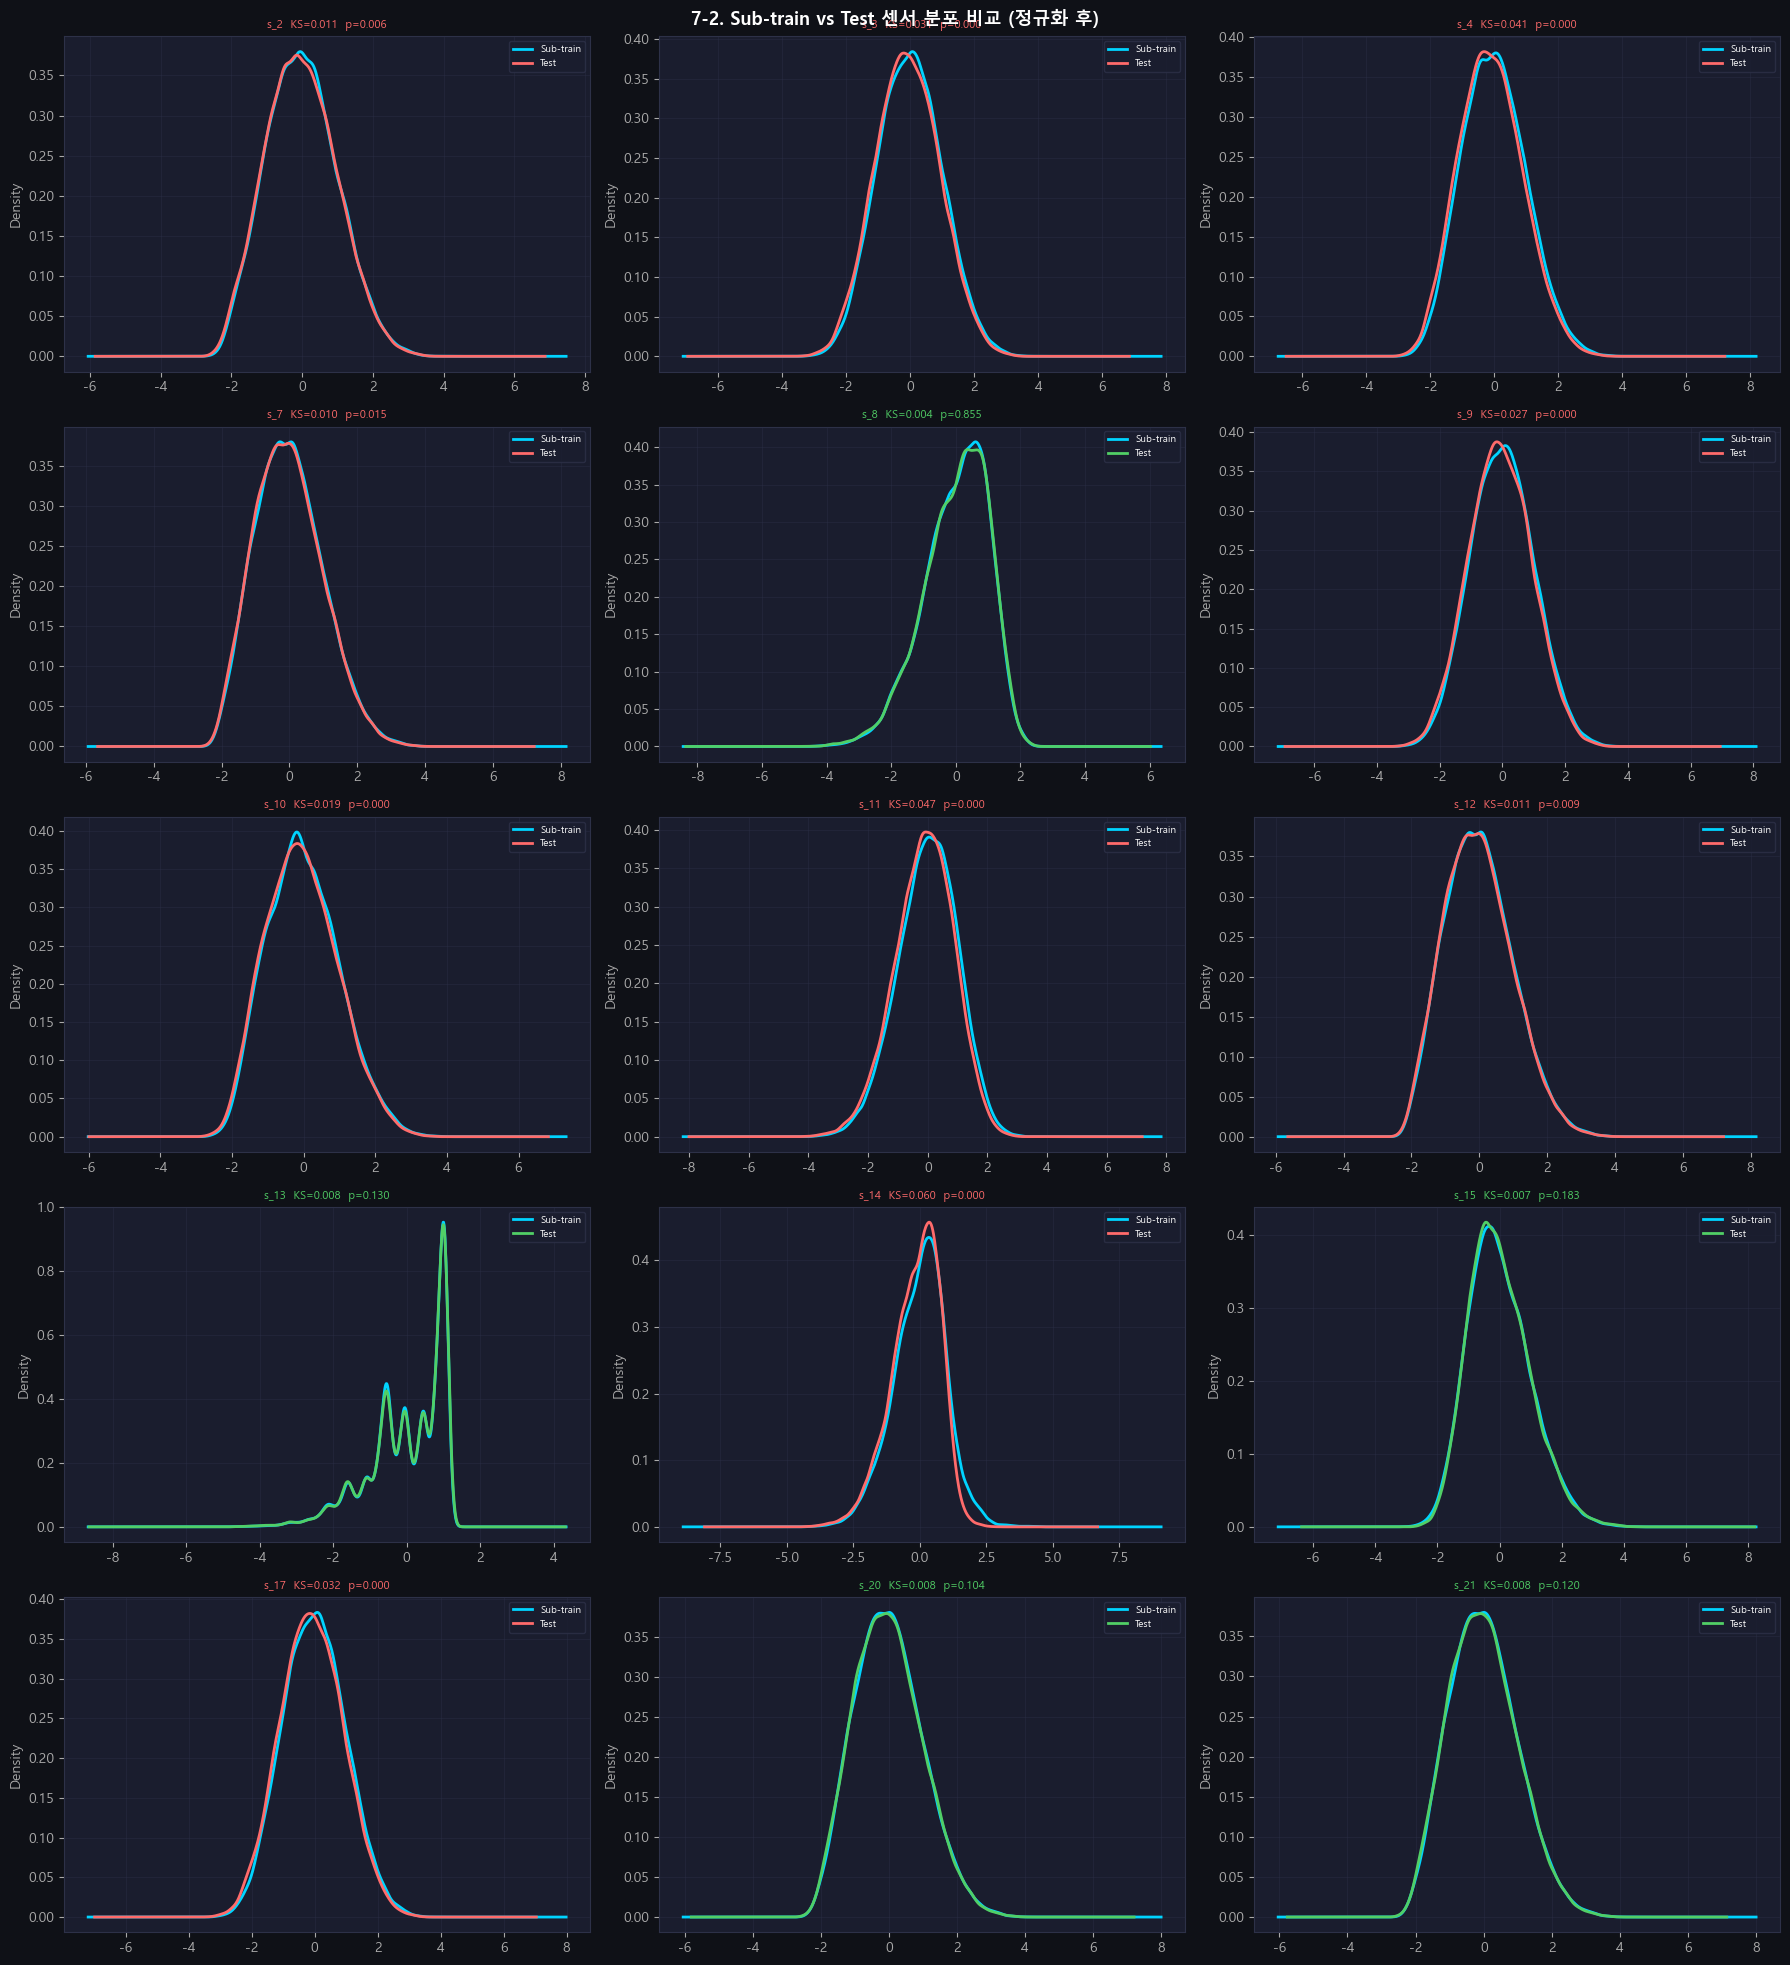

,KS 통계량,p-value,판정
센서,,,
s_2,0.0114,0.0056,분포 다름 ⚠️
s_3,0.0315,0.0000,분포 다름 ⚠️
s_4,0.0412,0.0000,분포 다름 ⚠️
s_7,0.0105,0.0147,분포 다름 ⚠️
s_8,0.0040,0.8549,분포 유사 ✅
s_9,0.0269,0.0000,분포 다름 ⚠️
s_10,0.0193,0.0000,분포 다름 ⚠️
s_11,0.0467,0.0000,분포 다름 ⚠️
s_12,0.0109,0.0093,분포 다름 ⚠️



분포 유사 센서: 5/15개
✅ 7-2 완료


In [7]:
# ── 7-2. Train vs Test 분포 비교 (KS 검정) ───────────────────
from scipy.stats import ks_2samp

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
fig.suptitle('7-2. Sub-train vs Test 센서 분포 비교 (정규화 후)', fontsize=13, fontweight='bold')

ks_rows = []
for ax, s in zip(axes.flat, USEFUL_SENSORS):
    train_vals = subtrain_s4[s].dropna()
    test_vals  = test_s4[s].dropna()
    stat, p    = ks_2samp(train_vals, test_vals)
    ks_rows.append({'센서': s, 'KS 통계량': round(stat,4), 'p-value': round(p,4),
                    '판정': '분포 유사 ✅' if p > 0.05 else '분포 다름 ⚠️'})
    color = C[2] if p > 0.05 else C[1]
    try:
        train_vals.plot.kde(ax=ax, color=C[0], lw=2, label='Sub-train')
        test_vals.plot.kde( ax=ax, color=color, lw=2, label='Test')
    except: pass
    ax.set_title(f'{s}  KS={stat:.3f}  p={p:.3f}', fontsize=8,
                 color=C[2] if p > 0.05 else C[1])
    ax.legend(fontsize=7)

for ax in axes.flat[len(USEFUL_SENSORS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

ks_df = pd.DataFrame(ks_rows).set_index('센서')
display(ks_df)
print(f'\n분포 유사 센서: {(ks_df["판정"]=="분포 유사 ✅").sum()}/{len(USEFUL_SENSORS)}개')
print('✅ 7-2 완료')

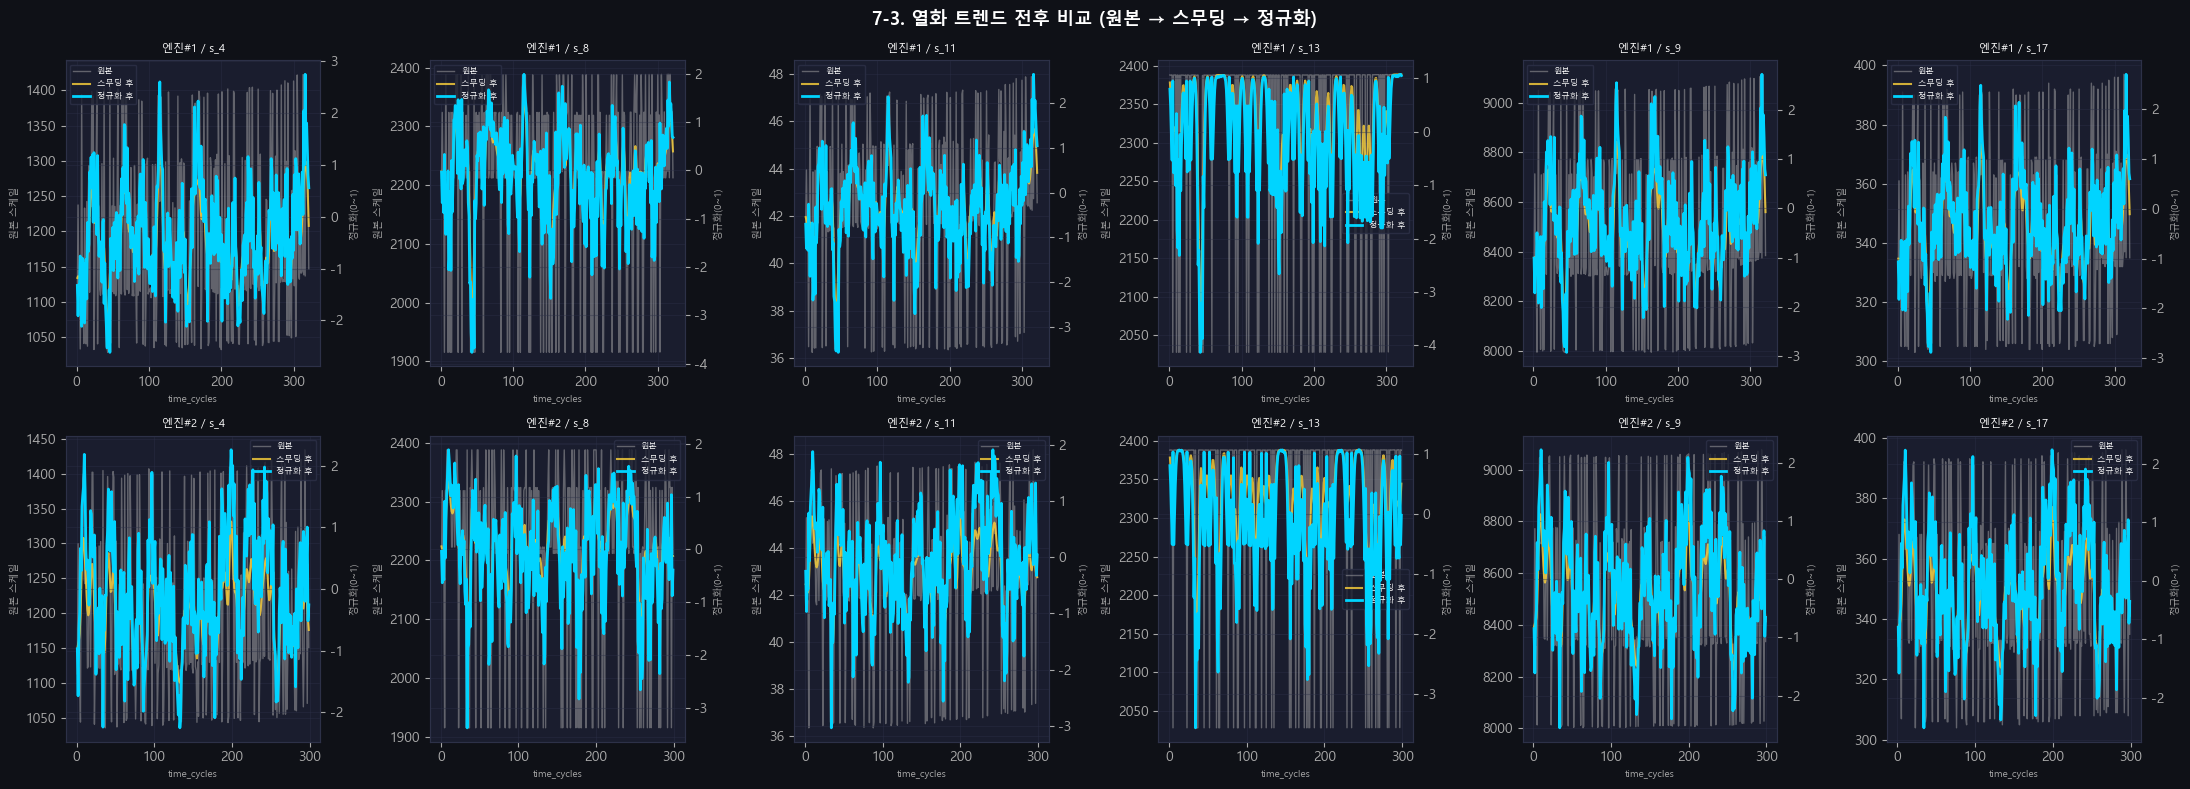

✅ 7-3 완료


In [8]:
# 7-3 수정: 원본 → 스무딩 후 → 정규화 후 3단계 비교
sample_sensors = ['s_4','s_8','s_11','s_13','s_9','s_17']
sample_units   = subtrain['unit_nr'].unique()[:2]

fig, axes = plt.subplots(len(sample_units), len(sample_sensors), figsize=(22, 8))
fig.suptitle('7-3. 열화 트렌드 전후 비교 (원본 → 스무딩 → 정규화)',
             fontsize=13, fontweight='bold')

for ri, uid in enumerate(sample_units):
    raw_data    = train_raw[train_raw['unit_nr']==uid].sort_values('time_cycles')
    smooth_data = train_s3[train_s3['unit_nr']==uid].sort_values('time_cycles')
    norm_data   = subtrain_s4[subtrain_s4['unit_nr']==uid].sort_values('time_cycles')
    for ci, s in enumerate(sample_sensors):
        ax = axes[ri, ci]
        ax2 = ax.twinx()  # 정규화 후는 다른 y축
        ax.plot(raw_data['time_cycles'],    raw_data[s],
                color=GRAY, lw=1, alpha=0.5, label='원본')
        ax.plot(smooth_data['time_cycles'], smooth_data[s],
                color=C[3], lw=1.5, alpha=0.8, label='스무딩 후')
        ax2.plot(norm_data['time_cycles'],  norm_data[s],
                 color=C[0], lw=2, label='정규화 후')
        ax.set_title(f'엔진#{uid} / {s}', fontsize=8)
        ax.set_xlabel('time_cycles', fontsize=7)
        ax.set_ylabel('원본 스케일', fontsize=7)
        ax2.set_ylabel('정규화(0~1)', fontsize=7)
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1+lines2, labels1+labels2, fontsize=6)

plt.tight_layout(); plt.show()
print('✅ 7-3 완료')

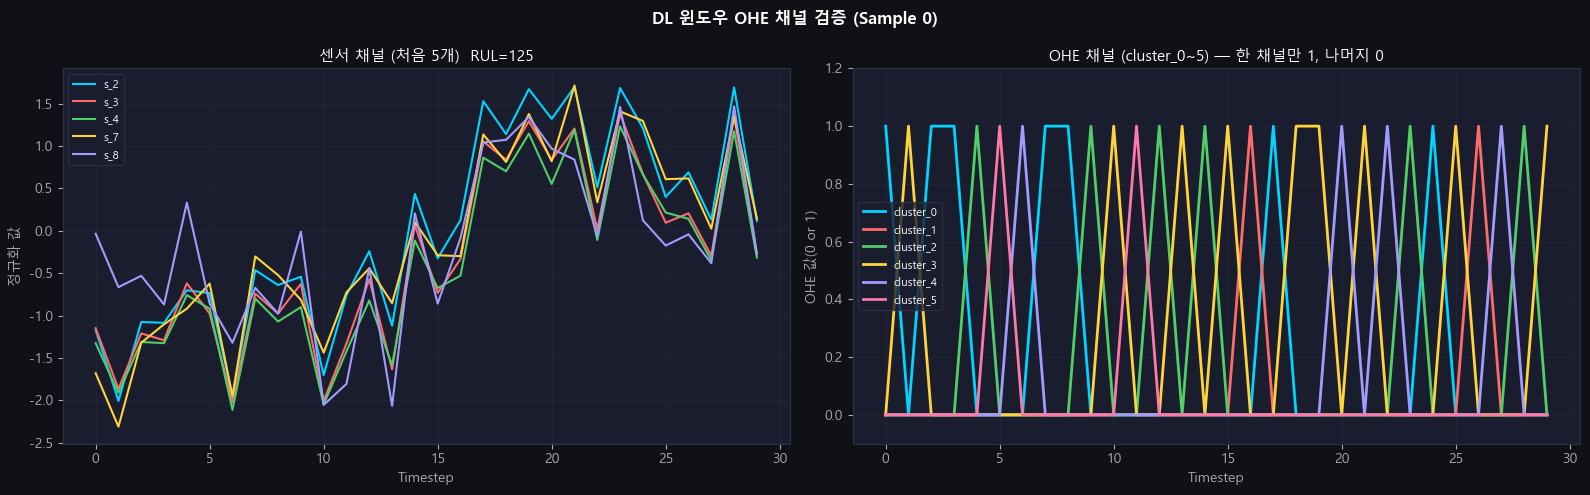


OHE 정합성 (모든 타임스텝 합=1): ✅
활성 클러스터: ['cluster_0']

클러스터별 샘플 수 (subtrain):
  cluster_0: 12409개
  cluster_1: 7385개
  cluster_2: 7371개
  cluster_3: 7307개
  cluster_4: 7447개
  cluster_5: 7375개


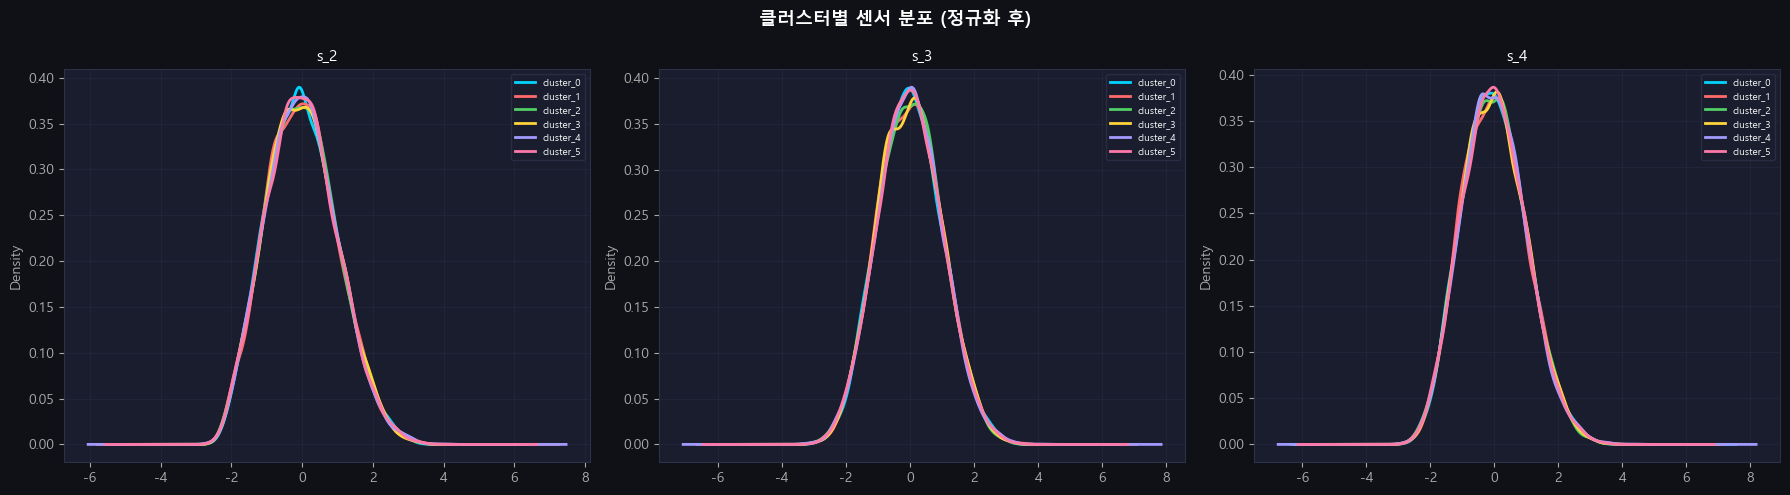

In [9]:
# ── OHE 채널 확인: 마지막 6채널이 0/1인지 검증 ───────────────────────────
sample_window = X_subtrain_dl[0]
ohe_channels  = sample_window[:, len(USEFUL_SENSORS):]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DL 윈도우 OHE 채널 검증 (Sample 0)', fontsize=12, fontweight='bold')

ax = axes[0]
for fi in range(min(5, len(USEFUL_SENSORS))):
    ax.plot(sample_window[:, fi], color=C[fi], lw=1.5, label=USEFUL_SENSORS[fi])
ax.set_title(f'센서 채널 (처음 5개)  RUL={y_subtrain_dl[0]:.0f}')
ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값'); ax.legend(fontsize=8)

ax = axes[1]
for ci in range(N_CLUSTERS):
    ax.plot(ohe_channels[:, ci], color=CLUSTER_COLORS[ci],
            lw=2, label=f'cluster_{ci}')
ax.set_title('OHE 채널 (cluster_0~5) — 한 채널만 1, 나머지 0')
ax.set_xlabel('Timestep'); ax.set_ylabel('OHE 값(0 or 1)')
ax.set_ylim(-0.1, 1.2); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# OHE 정합성: 각 타임스텝에서 OHE 합 = 1
ohe_rowsums = ohe_channels.sum(axis=1)
ok = np.all(ohe_rowsums == 1)
print(f'\nOHE 정합성 (모든 타임스텝 합=1): {"✅" if ok else "❌"}')
print(f'활성 클러스터: {[f"cluster_{i}" for i in np.where(ohe_channels[0] == 1)[0]]}')

# 클러스터별 샘플 수 확인
print('\n클러스터별 샘플 수 (subtrain):')
cluster_counts = subtrain_s4['op_cluster'].value_counts().sort_index()
for c, cnt in cluster_counts.items():
    print(f'  cluster_{c}: {cnt}개')

# 클러스터별 센서 분포 (대표 센서 3개)
show_s = USEFUL_SENSORS[:3]
fig, axes = plt.subplots(1, len(show_s), figsize=(18, 5))
fig.suptitle('클러스터별 센서 분포 (정규화 후)', fontsize=13, fontweight='bold')
for ax, s in zip(axes, show_s):
    for c, color in zip(range(N_CLUSTERS), CLUSTER_COLORS):
        data = subtrain_s4[subtrain_s4['op_cluster']==c][s].dropna()
        if len(data) > 1:
            try:
                data.plot.kde(ax=ax, color=color, lw=2, label=f'cluster_{c}')
            except: pass
    ax.set_title(f'{s}'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CSV 저장 & 최종 요약
# ============================================================
# OUTPUT_DIR = 'preprocessed_FD004'
OUTPUT_DIR = 'preprocessed_FD004_exp'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 파일명 자동 생성 (CONFIG 값 조합) ────────────────────────
# prefix = f'FD004_cap{RUL_CAP}_sig{GAUSS_SIGMA}_win{WINDOW_SIZE}_standard'
prefix = f'FD004_cap{RUL_CAP}_sig{GAUSS_SIGMA}_win{WINDOW_SIZE}'
print(f'📁 저장 prefix: {prefix}')

# ── 파일 경로 ─────────────────────────────────────────────────
dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)

dl_subtrain_path = os.path.join(dl_dir, f'{prefix}_dl_subtrain_long.csv')
dl_valid_path    = os.path.join(dl_dir, f'{prefix}_dl_valid_long.csv')
dl_test_path     = os.path.join(dl_dir, f'{prefix}_dl_test_long.csv')
rul_path         = os.path.join(OUTPUT_DIR, f'{prefix}_test_RUL.csv')
dl_feat_path     = os.path.join(OUTPUT_DIR, f'{prefix}_dl_features.txt')
scaler_path    = os.path.join(OUTPUT_DIR, f'{prefix}_scalers_by_cluster.pkl')
kmeans_path    = os.path.join(OUTPUT_DIR, f'{prefix}_kmeans.pkl')
op_scaler_path = os.path.join(OUTPUT_DIR, f'{prefix}_op_scaler.pkl')

# ── DL Long Format CSV 저장 ───────────────────────────────────
dl_subtrain_long.to_csv(dl_subtrain_path, index=False, encoding='utf-8-sig')
dl_valid_long.to_csv(dl_valid_path,       index=False, encoding='utf-8-sig')
dl_test_long.to_csv(dl_test_path,         index=False, encoding='utf-8-sig')
rul_df.to_csv(rul_path,                   index=False, encoding='utf-8-sig')

# ── Scaler & 피처 목록 저장 ─────────────────────────────────────────────────
joblib.dump(scalers,   scaler_path)
joblib.dump(kmeans,    kmeans_path)
joblib.dump(op_scaler, op_scaler_path)
# with open(dl_feat_path, 'w', encoding='utf-8') as f:
#     for col in DL_FEATURES:
#         f.write(f'{col}\n')

# ── 저장 검증 ─────────────────────────────────────────────────
chk_sub = pd.read_csv(dl_subtrain_path)
chk_val = pd.read_csv(dl_valid_path)
chk_te  = pd.read_csv(dl_test_path)

print('=' * 74)
print('  FD004 DL 전처리 파이프라인 완료')
print('=' * 74)
print()
print('■ 전처리 파이프라인')
print(f'  수동 제거: {MANUAL_REMOVE}  |  수동 유지: {MANUAL_KEEP}')
print(f'  → RUL Cap={RUL_CAP} → Gaussian(σ={GAUSS_SIGMA})')
print(f'  → Validation 분할(80:20, random_state={RANDOM_STATE})')
print(f'  → 클러스터별 {SCALER_TYPE} 정규화  |  KMeans k={N_CLUSTERS}')
print()
print('■ DL 분기 — 슬라이딩 윈도우 Long Format')

dl_summary = pd.DataFrame({
    '구분'       : ['Sub-train', 'Validation', 'Test'],
    'shape'      : [str(chk_sub.shape), str(chk_val.shape), str(chk_te.shape)],
    '샘플 수'    : [X_subtrain_dl.shape[0], X_valid_dl.shape[0], X_test_dl.shape[0]],
    'window_size': [WINDOW_SIZE] * 3,
    'DL피처 수'  : [len(DL_FEATURES)] * 3,
    '파일(dl/)'  : [os.path.basename(dl_subtrain_path),
                    os.path.basename(dl_valid_path),
                    os.path.basename(dl_test_path)],
}).set_index('구분')
display(dl_summary)

print()
print(f'📄 저장 경로: {os.path.abspath(OUTPUT_DIR)}/')
print()
print('── DL 활용법 (Long Format → 3D 복원) ──')
print(f'  df  = pd.read_csv("dl/{prefix}_dl_subtrain_long.csv")')
print(f'  grp = df.groupby("sample_id")')
print(f'  X   = np.stack([grp.get_group(i)[DL_FEATURES].values')
print(f'                  for i in range(df["sample_id"].nunique())])  # (N, {WINDOW_SIZE}, {len(DL_FEATURES)})')
print(f'  y   = df.groupby("sample_id")["RUL"].last().values')

📁 저장 prefix: FD004_cap125_sig2_win30_standard
  FD004 DL 전처리 파이프라인 완료

■ 전처리 파이프라인
  수동 제거: ['s_1', 's_5', 's_6', 's_18', 's_19']  |  수동 유지: []
  → RUL Cap=125 → Gaussian(σ=2)
  → Validation 분할(80:20, random_state=42)
  → 클러스터별 standard 정규화  |  KMeans k=6

■ DL 분기 — 슬라이딩 윈도우 Long Format


,shape,샘플 수,window_size,DL피처 수,파일(dl/)
구분,,,,,
Sub-train,"(1305690, 24)",43523,30,21,FD004_cap125_sig2_win30_standard_dl_subtrain_l...
Validation,"(315150, 24)",10505,30,21,FD004_cap125_sig2_win30_standard_dl_valid_long...
Test,"(7440, 24)",248,30,21,FD004_cap125_sig2_win30_standard_dl_test_long.csv



📄 저장 경로: c:\sparta_project_4_team16\YJ\preprocessed_FD004_exp/

── DL 활용법 (Long Format → 3D 복원) ──
  df  = pd.read_csv("dl/FD004_cap125_sig2_win30_standard_dl_subtrain_long.csv")
  grp = df.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df["sample_id"].nunique())])  # (N, 30, 21)
  y   = df.groupby("sample_id")["RUL"].last().values
